# Federated probabilistic load forecasting: paper 3 core (v5, cleaned)

Pipeline: FedAvg backbones -> rollout under blended history degradation
(`level` in {0, 0.25, 0.5, 0.75, 1}) -> conformal calibration (modular, CQR,
integrated) -> baselines, economics, foundation-model swap, significance,
figures, digital twin.

Cells are ordered so each one runs after the cell that produces its inputs.
Run top to bottom. Sections 4 and 7 are the long ones.


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, time, warnings, numpy as np, pandas as pd
import torch, torch.nn as nn
from collections import defaultdict
warnings.filterwarnings("ignore")

PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/paper3_fed_load"
CLI_DIR = os.path.join(PROJECT_DIR, "bdg2_federated_out", "clients")
OUT_DIR = os.path.join(PROJECT_DIR, "model_out"); os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
QUANTILES=[0.1,0.5,0.9]; ALPHA=0.2
ROUNDS=15; LOCAL_EPOCHS=2; LR=1e-3; HIDDEN=64; BATCH=256; SEED=0
DEGRADE_TEMP    = False
DEGRADE_HISTORY = True
LEVELS = [0.0, 0.25, 0.5, 0.75, 1.0]   # dose-response grid (0 = true history, 1 = full climatology)
torch.manual_seed(SEED); np.random.seed(SEED)

BASE_FEATS = ["airTemperature","hod_sin","hod_cos","dow_sin","dow_cos","doy_sin","doy_cos",
              "load_lag1","load_lag2","load_lag24","load_ma3","load_ma6","load_ma24"]
DEG = ["dewTemperature","cloudCoverage","precipDepth1HR","seaLvlPressure","windSpeed","windDirection"]
CAUSAL = ["load_lag1","load_lag2","load_lag24","load_ma3","load_ma6","load_ma24"]
FEATS_RECON = BASE_FEATS + [f"{c}__reconstructed" for c in DEG]
FEATS_OBS   = BASE_FEATS + [f"{c}__observed" for c in DEG]
ALL_NEEDED  = sorted(set(FEATS_RECON) | set(FEATS_OBS))
DYN = set(CAUSAL)
print("device:", DEVICE, "| levels:", LEVELS)
print(torch.__version__)


Mounted at /content/drive
device: cpu | levels: [0.0, 0.25, 0.5, 0.75, 1.0]
2.11.0+cpu


## 2. Clients

In [2]:
def load_client(path):
    d = pd.read_parquet(path)
    for col in ALL_NEEDED:
        if col not in d.columns: d[col] = np.nan
    tr = d[d.split=="train"].dropna(subset=CAUSAL+["load"])
    if len(tr) < 200: return None
    mu = np.nan_to_num(np.nanmean(tr[FEATS_RECON].values,axis=0),nan=0.0)
    sd = np.nan_to_num(np.nanstd(tr[FEATS_RECON].values,axis=0),nan=1.0); sd[sd==0]=1.0
    muy=tr["load"].mean(); sdy=tr["load"].std() or 1.0
    def mat(split,feats):
        s=d[d.split==split].dropna(subset=CAUSAL+["load"])
        X=np.nan_to_num((s[feats].values-mu)/sd,nan=0.0)
        y=((s["load"].values-muy)/sdy).reshape(-1,1)
        return (torch.tensor(X,dtype=torch.float32), torch.tensor(y,dtype=torch.float32), s["load"].values.reshape(-1,1))
    return {"train":mat("train",FEATS_RECON), "muy":muy,"sdy":sdy,"n_train":len(tr)}

clients={}
for f in sorted(glob.glob(os.path.join(CLI_DIR,"*.parquet"))):
    c=load_client(f)
    if c is not None: clients[os.path.basename(f).replace(".parquet","")]=c
print("loaded", len(clients), "clients")

loaded 60 clients


## 3. Model and FedAvg

In [ ]:
D=len(FEATS_RECON)
def make_model(out_dim):
    return nn.Sequential(nn.Linear(D,HIDDEN),nn.ReLU(),nn.Dropout(0.1),
                         nn.Linear(HIDDEN,HIDDEN),nn.ReLU(),nn.Linear(HIDDEN,out_dim))
def pinball(pred,y,qs):
    loss=0.0
    for i,q in enumerate(qs):
        e=y[:,0]-pred[:,i]; loss=loss+torch.maximum(q*e,(q-1)*e).mean()
    return loss/len(qs)
def train_local(model,X,y,loss_fn,epochs,lr):
    model.train(); opt=torch.optim.Adam(model.parameters(),lr=lr); X,y=X.to(DEVICE),y.to(DEVICE); n=len(X)
    for _ in range(epochs):
        perm=torch.randperm(n)
        for i in range(0,n,BATCH):
            idx=perm[i:i+BATCH]; opt.zero_grad(); loss_fn(model(X[idx]),y[idx]).backward(); opt.step()
    return {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
def avg_states(states,w):
    w=np.array(w,float); w=w/w.sum()
    return {k:sum(states[j][k].float()*w[j] for j in range(len(states))) for k in states[0]}
def fedavg(out_dim,loss_fn):
    gm=make_model(out_dim).to(DEVICE); g={k:v.cpu().clone() for k,v in gm.state_dict().items()}
    for r in range(ROUNDS):
        states,ns=[],[]
        for c in clients.values():
            m=make_model(out_dim).to(DEVICE); m.load_state_dict(g); X,y,_=c["train"]
            states.append(train_local(m,X,y,loss_fn,LOCAL_EPOCHS,LR)); ns.append(c["n_train"])
        g=avg_states(states,ns)
        if (r+1)%5==0: print(f"  round {r+1}/{ROUNDS}")
    gm.load_state_dict(g); gm.eval(); return gm
print("ready")

ready


## 4. Train the two backbones

Run the first cell once, then use the loader on later sessions.

In [ ]:
t0=time.time(); print("integrated..."); model_int=fedavg(len(QUANTILES),lambda p,y:pinball(p,y,QUANTILES)); print(f"  {time.time()-t0:.0f}s")
t0=time.time(); print("modular...");    mse=nn.MSELoss(); model_pt=fedavg(1,lambda p,y:mse(p,y)); print(f"  {time.time()-t0:.0f}s")

integrated...
  round 5/15
  round 10/15
  round 15/15
  224s
modular...
  round 5/15
  round 10/15
  round 15/15
  152s


In [ ]:
torch.save(model_int.state_dict(), os.path.join(OUT_DIR, "model_int.pt"))
torch.save(model_pt.state_dict(),  os.path.join(OUT_DIR, "model_pt.pt"))

In [ ]:
#4 load trained models
model_int = make_model(len(QUANTILES)).to(DEVICE)
model_int.load_state_dict(torch.load(os.path.join(OUT_DIR, "model_int.pt"), map_location=DEVICE))
model_int.eval()
model_pt = make_model(1).to(DEVICE)
model_pt.load_state_dict(torch.load(os.path.join(OUT_DIR, "model_pt.pt"), map_location=DEVICE))
model_pt.eval()
print("models loaded from disk")

models loaded from disk


## 5. Rollout engine

In [ ]:
def compute_scalers(d):
    tr=d[d.split=="train"].dropna(subset=CAUSAL+["load"])
    mu=np.nan_to_num(np.nanmean(tr[FEATS_RECON].values,axis=0),nan=0.0)
    sd=np.nan_to_num(np.nanstd(tr[FEATS_RECON].values,axis=0),nan=1.0); sd[sd==0]=1.0
    return mu,sd,tr["load"].mean(),(tr["load"].std() or 1.0)

def design_cal(df):
    return np.column_stack([np.ones(len(df)), df["hod_sin"].values, df["hod_cos"].values,
                            df["doy_sin"].values, df["doy_cos"].values,
                            df["dow_sin"].values, df["dow_cos"].values])

@torch.no_grad()
def rollout(name, kind, cond, split="test", seed_from="calib", level=1.0):
    d=pd.read_parquet(os.path.join(CLI_DIR,name+".parquet"))
    for col in ALL_NEEDED:
        if col not in d.columns: d[col]=np.nan
    mu,sd,muy,sdy=compute_scalers(d)
    recon=(cond=="reconstructed")
    beta_t=None
    if DEGRADE_TEMP and recon:
        trt=d[d.split=="train"].dropna(subset=["airTemperature","hod_sin","doy_sin"])
        beta_t,*_=np.linalg.lstsq(design_cal(trt), trt["airTemperature"].values, rcond=None)
    suf="__observed" if cond=="observed" else "__reconstructed"
    feat=BASE_FEATS+[f"{c}{suf}" for c in DEG]
    dynpos={nm:i for i,nm in enumerate(feat) if nm in DYN}
    stat=[(i,nm) for i,nm in enumerate(feat) if nm not in DYN]
    te=d[d.split==split].copy()
    N=len(te)
    if beta_t is not None:
        te["airTemperature"]=design_cal(te)@beta_t
    ss=d[d.split==seed_from]["load"]; ssf=ss[np.isfinite(ss.values)]
    if len(ssf)>=24:
        seed_idx=ssf.index[-24:]; seed_vals=ssf.values[-24:]
    else:
        seed_idx=te.index[:24]; seed_vals=np.full(24,muy)
    yact=te["load"].values
    all_idx=seed_idx.append(te.index)
    full_true=np.r_[seed_vals,yact]
    if DEGRADE_HISTORY and recon and level>0:
        trl=d[d.split=="train"].dropna(subset=["load"])
        clim=trl.groupby([trl.index.hour,trl.index.dayofweek])["load"].mean().to_dict()
        gmean=trl["load"].mean()
        full_clim=np.array([clim.get((t.hour,t.dayofweek),gmean) for t in all_idx])
        full_used=(1-level)*full_true + level*full_clim
    else:
        full_used=full_true
    off=24
    S=te[[nm for _,nm in stat]].values.astype(float)
    model=model_int if kind=="int" else model_pt
    lo=np.empty(N); md_=np.empty(N); up=np.empty(N); pt=np.empty(N)
    for b0 in range(0,N,24):
        b1=min(b0+24,N); buf=list(full_used[off+b0-24:off+b0])
        for i in range(b0,b1):
            x=np.empty(len(feat))
            for j,(ix,nm) in enumerate(stat): x[ix]=S[i,j]
            x[dynpos["load_lag1"]]=buf[-1]; x[dynpos["load_lag2"]]=buf[-2]; x[dynpos["load_lag24"]]=buf[-24]
            x[dynpos["load_ma3"]]=np.mean(buf[-3:]); x[dynpos["load_ma6"]]=np.mean(buf[-6:]); x[dynpos["load_ma24"]]=np.mean(buf[-24:])
            xs=np.nan_to_num((x-mu)/sd,nan=0.0)
            p=model(torch.tensor(xs,dtype=torch.float32,device=DEVICE).unsqueeze(0)).cpu().numpy()[0]
            if kind=="int":
                p=np.sort(p); lo[i]=p[0]*sdy+muy; md_[i]=p[1]*sdy+muy; up[i]=p[2]*sdy+muy; cen=md_[i]
            else:
                pt[i]=p[0]*sdy+muy; cen=pt[i]
            buf.append(cen); buf.pop(0)
    return (yact,lo,md_,up) if kind=="int" else (yact,pt)
print("rollout ready")

rollout ready


## 6. Calibrators: modular conformal and CQR

In [ ]:
def qhi(scores):
    scores=scores[np.isfinite(scores)]
    return np.quantile(scores, min(0.999,(1-ALPHA)*(1+1/max(len(scores),1))))

def calibrate(level):
    mod_pool=[]; cqr_pool=[]; loc_mod={}; loc_cqr={}
    for name in clients:
        y,pt=rollout(name,"pt","reconstructed",split="calib",seed_from="val",level=level)
        sc=np.abs(y-pt)
        yi,lo,md_,up=rollout(name,"int","reconstructed",split="calib",seed_from="val",level=level)
        E=np.maximum(lo-yi, yi-up)                 # CQR nonconformity
        loc_mod[name]=qhi(sc); loc_cqr[name]=qhi(E)
        mod_pool.append(sc[np.isfinite(sc)]); cqr_pool.append(E[np.isfinite(E)])
    return qhi(np.concatenate(mod_pool)), qhi(np.concatenate(cqr_pool)), loc_mod, loc_cqr
print("calibrators ready")

calibrators ready


## 7. Dose-response sweep

The long step, 15 to 25 min. Writes `results_doseresponse.csv`, `rollout_resid_L1.npy` and `sweep.pkl`.

In [ ]:
# metric helpers are defined once, in section 2

sweep=defaultdict(lambda:{"y":[],"lo":[],"md":[],"up":[]})
def put(key,y,lo,md_,up):
    s=sweep[key]; s["y"].append(y); s["lo"].append(lo); s["md"].append(md_); s["up"].append(up)

for lv in LEVELS:
    t0=time.time()
    fq, Qcqr, loc_mod, loc_cqr = calibrate(lv)
    for name in clients:
        yi,lo,md_,up = rollout(name,"int","reconstructed",level=lv)
        yp,pt       = rollout(name,"pt","reconstructed",level=lv)
        put((lv,"integrated"),  yi, lo, md_, up)
        put((lv,"cqr_fed"),     yi, lo-Qcqr, md_, up+Qcqr)
        put((lv,"cqr_local"),   yi, lo-loc_cqr[name], md_, up+loc_cqr[name])
        put((lv,"modular_fed"), yi, pt-fq, pt, pt+fq)
        put((lv,"modular_local"),yi, pt-loc_mod[name], pt, pt+loc_mod[name])
    print(f"level {lv:.2f} done in {time.time()-t0:.0f}s")

rows=[]
for (lv,scheme),s in sweep.items():
    y=np.concatenate(s["y"]); lo=np.concatenate(s["lo"]); md_=np.concatenate(s["md"]); up=np.concatenate(s["up"])
    r=imetrics(y,lo,md_,up); r.update(level=lv, scheme=scheme); rows.append(r)
sweep_df=pd.DataFrame(rows)[["level","scheme","MAE","WAPE","PICP80","MPIW80","MIS80","QS"]].sort_values(["scheme","level"]).round(2)
sweep_df.to_csv(os.path.join(OUT_DIR,"results_doseresponse.csv"),index=False)
print("saved results_doseresponse.csv")
sweep_df
# persist full-degradation residuals so cost_optimize survives a disconnect
_s1 = sweep[(max(LEVELS), "integrated")]
_y1 = np.concatenate([np.asarray(a).ravel() for a in _s1["y"]])
_m1 = np.concatenate([np.asarray(a).ravel() for a in _s1["md"]])
np.save(os.path.join(OUT_DIR, "rollout_resid_L1.npy"), _y1 - _m1)
print("saved rollout_resid_L1.npy")

level 0.00 done in 112s


KeyboardInterrupt: 

In [ ]:
exec(open(f"{PROJECT_DIR}/sweep7.py").read())

sweeping 5 levels x 60 clients
level 0.00 done in 118s
level 0.25 done in 117s
level 0.50 done in 116s
level 0.75 done in 116s
level 1.00 done in 116s
sweep OK: 25 keys, levels [0.0, 0.25, 0.5, 0.75, 1.0]
saved results_doseresponse.csv
saved rollout_resid_L1.npy
saved sweep_all5.pkl, 25 keys, 82.3 MB

next, in a new cell:
  BASELINE_LEVELS = [0.0, 0.25, 0.5, 0.75, 1.0]
  exec(open(f"{PROJECT_DIR}/baselines.py").read())
  exec(open(f"{PROJECT_DIR}/make_figs.py").read())
watch for: width ratio: [1.35, 1.56, 1.72, 1.84, 1.96]


In [ ]:
import pickle
with open(os.path.join(OUT_DIR, "sweep.pkl"), "wb") as f:
    pickle.dump({k: {kk: [np.asarray(a) for a in vv] for kk, vv in v.items()}
                 for k, v in sweep.items()}, f)
print("saved sweep.pkl,", len(sweep), "keys")

saved sweep.pkl, 5 keys


## 8. Derived artifacts

`resid_structured.npz` feeds the cost and bandit experiments and the twin replay; `twin_stream.npz` feeds the live twin.

In [ ]:
# ---- dump structured residuals ----
# Feeds bandit_seasons.py, cost_optimize.py and twin_replay_signed.py.
import numpy as np, pandas as pd, os

SCHEME = "modular_local"   # point-model residuals: md field holds the point forecast
s0, s1 = sweep[(0.0, SCHEME)], sweep[(1.0, SCHEME)]
names  = list(clients.keys())               # same order put() appended in

payload = {}
for k, name in enumerate(names):
    e0 = np.asarray(s0["y"][k]).ravel() - np.asarray(s0["md"][k]).ravel()  # clean residuals
    e1 = np.asarray(s1["y"][k]).ravel() - np.asarray(s1["md"][k]).ravel()  # degraded residuals
    d  = pd.read_parquet(os.path.join(CLI_DIR, name + ".parquet"))
    hod = d[d.split == "test"].index.hour.values                            # hour tags
    assert len(hod) == len(e1), (name, len(hod), len(e1))
    payload[f"e0_{k}"], payload[f"e1_{k}"], payload[f"hod_{k}"] = e0, e1, hod

np.savez_compressed(os.path.join(OUT_DIR, "resid_structured.npz"), **payload)
print("saved", len(names), "buildings; example lens:",
      len(payload["e1_0"]), len(payload["hod_0"]))

In [ ]:
# regenerate twin_stream.npz without the sweep
import numpy as np, os, time
payload = {}
for lv, tag in ((0.0, "0"), (1.0, "1")):
    t0 = time.time()
    for k, name in enumerate(clients):
        y, pt = rollout(name, "pt", "reconstructed", level=lv)
        payload[f"y{tag}_{k}"] = y.ravel()
        payload[f"p{tag}_{k}"] = pt.ravel()
    print(f"level {lv} ({time.time()-t0:.0f}s)")
np.savez_compressed(os.path.join(OUT_DIR, "twin_stream.npz"), **payload)
print("saved twin_stream.npz,", len(clients), "buildings")

level 0.0 (37s)
level 1.0 (35s)
saved twin_stream.npz, 60 buildings


## 9. Calibration transfer, adaptive variants, step-size grid

computing calibrators per level...
  calibrated @ 0.00  (51s)
  calibrated @ 0.25  (55s)
  calibrated @ 0.50  (57s)
  calibrated @ 0.75  (54s)
  calibrated @ 1.00  (54s)
test rollouts per level...
  test rollout @ 0.00  (76s)
  test rollout @ 0.25  (80s)
  test rollout @ 0.50  (79s)
  test rollout @ 0.75  (79s)
  test rollout @ 1.00  (79s)
saved results_calibtransfer.csv


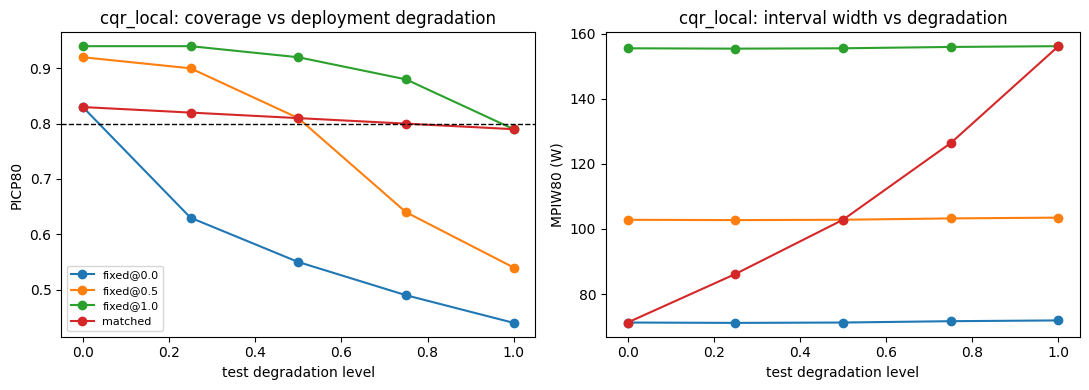


PICP80 for cqr_local (rows = calibrated at, cols = tested at):


test_level,0.00,0.25,0.50,0.75,1.00
calib,,,,,
fixed@0.0,0.83,0.63,0.55,0.49,0.44
fixed@0.5,0.92,0.90,0.81,0.64,0.54
fixed@1.0,0.94,0.94,0.92,0.88,0.79
matched,0.83,0.82,0.81,0.80,0.79


In [ ]:
exec(open(f"{PROJECT_DIR}/calib_transfer.py").read())

In [ ]:
exec(open(f"{PROJECT_DIR}/adaptive_conformal.py").read())

rolling out calib + test (point) per level...


NameError: name 'clients' is not defined

In [ ]:
exec(open(f"{PROJECT_DIR}/grid_adaptive.py").read())

rolling out calib + test (point) per level (one-time)...


NameError: name 'clients' is not defined

In [ ]:
# adaptive_cqr.py — the ACL wrapped on CQR_local, filling the adaptive-CQR cell.
import os, time
import numpy as np, pandas as pd

GAMMA, WMAX = 0.02, 360

# metric helpers, lifted out of cell 7 so the sweep need not be rerun
def qs_score(y, levels):
    return np.mean([np.mean(np.maximum(q*(y-p), (q-1)*(y-p)))
                    for q, p in levels.items()])

def imetrics(y, lo, md_, up):
    y = y.ravel(); lo = lo.ravel(); md_ = md_.ravel(); up = up.ravel()
    m = np.isfinite(y) & np.isfinite(md_) & np.isfinite(lo) & np.isfinite(up)
    y, lo, md_, up = y[m], lo[m], md_[m], up[m]
    return dict(MAE=np.mean(np.abs(y-md_)),
                WAPE=100*np.sum(np.abs(y-md_))/(np.sum(np.abs(y))+1e-9),
                PICP80=np.mean((y >= lo) & (y <= up)), MPIW80=np.mean(up-lo),
                MIS80=np.mean((up-lo) + (2/ALPHA)*(lo-y)*(y < lo)
                              + (2/ALPHA)*(y-up)*(y > up)),
                QS=qs_score(y, {0.1: lo, 0.5: md_, 0.9: up}))

# 1) CQR nonconformity on calib, quantile rollouts on test, per level
print("rolling out calib + test (quantile) per level...")
cqr_calib = {lv: {} for lv in LEVELS}
test_int  = {lv: {} for lv in LEVELS}
for lv in LEVELS:
    t0 = time.time()
    for name in clients:
        yc, lo_c, md_c, up_c = rollout(name, "int", "reconstructed",
                                       split="calib", seed_from="val", level=lv)
        E = np.maximum(lo_c - yc, yc - up_c)          # CQR score
        cqr_calib[lv][name] = E[np.isfinite(E)]
        yt, lo_t, md_t, up_t = rollout(name, "int", "reconstructed",
                                       split="test", level=lv)
        test_int[lv][name] = (yt, lo_t, md_t, up_t)
    print(f"  level {lv:.2f}  ({time.time()-t0:.0f}s)")

# 2) ACL on the CQR score, seeded on CLEAN scores only
def run_adaptive_cqr(name, lv):
    y, lo, md_, up = test_int[lv][name]
    W = list(cqr_calib[0.0][name])                    # clean seed, as in the paper
    a = ALPHA; N = len(y); LO = np.empty(N); UP = np.empty(N)
    for b0 in range(0, N, 24):
        b1 = min(b0 + 24, N)
        r = np.quantile(np.array(W), min(0.999, max(0.001, 1 - a)))
        LO[b0:b1] = lo[b0:b1] - r; UP[b0:b1] = up[b0:b1] + r
        day = []
        for i in range(b0, b1):
            if np.isfinite(y[i]):
                err = 0 if (LO[i] <= y[i] <= UP[i]) else 1
                a = min(0.999, max(0.001, a + GAMMA * (ALPHA - err)))
                day.append(max(lo[i] - y[i], y[i] - up[i]))
        W.extend(day); W = W[-WMAX:]
    return y, LO, md_, UP

rows = []
for lv in LEVELS:
    Y, LOa, MD, UPa = [], [], [], []
    for name in clients:
        y, l, m_, u = run_adaptive_cqr(name, lv)
        Y.append(y); LOa.append(l); MD.append(m_); UPa.append(u)
    r = imetrics(np.concatenate(Y), np.concatenate(LOa),
                 np.concatenate(MD), np.concatenate(UPa))
    r.update(scheme="adaptive_cqr", test_level=lv); rows.append(r)

cdf = pd.DataFrame(rows)[["scheme","test_level","MAE","WAPE",
                          "PICP80","MPIW80","MIS80","QS"]].round(2)
cdf.to_csv(os.path.join(OUT_DIR, "results_adaptive_cqr.csv"), index=False)
print(cdf.to_string(index=False))

rolling out calib + test (quantile) per level...
  level 0.00  (68s)
  level 0.25  (71s)
  level 0.50  (69s)
  level 0.75  (68s)
  level 1.00  (69s)
      scheme  test_level   MAE  WAPE  PICP80  MPIW80  MIS80    QS
adaptive_cqr        0.00 20.58 20.93    0.80   61.47  81.71  6.15
adaptive_cqr        0.25 26.02 26.47    0.80   72.48  91.97  7.40
adaptive_cqr        0.50 32.42 32.98    0.79   86.67 108.48  9.02
adaptive_cqr        0.75 40.94 41.64    0.79  107.64 134.61 11.31
adaptive_cqr        1.00 50.08 50.94    0.79  131.70 162.19 13.75


## 10. Baselines

Writes `results_baselines.csv`.

In [ ]:
BASELINE_LEVELS = [0.0, 0.25, 0.5, 0.75, 1.0]
exec(open(f"{PROJECT_DIR}/baselines.py").read())


tuning at lambda=1 (each method at its own best setting)
     aci        gamma=0.005  PICP 0.606  MPIW   95.7  J $241
     aci        gamma=0.01   PICP 0.596  MPIW   94.7  J $245
     aci        gamma=0.02   PICP 0.578  MPIW   93.6  J $255
     aci        gamma=0.05   PICP 0.536  MPIW   94.2  J $280
     aci        gamma=0.1    PICP 0.485  MPIW   98.2  J $312
     -> aci: {'gamma': 0.005}
     acl        gamma=0.005  PICP 0.800  MPIW  137.0  J $254
     acl        gamma=0.01   PICP 0.799  MPIW  136.0  J $252
     acl        gamma=0.02   PICP 0.792  MPIW  132.9  J $250
     acl        gamma=0.05   PICP 0.755  MPIW  128.6  J $256
     acl        gamma=0.1    PICP 0.683  MPIW  125.0  J $273
     -> acl: {'gamma': 0.02}
     pid        eta_frac=0.002  PICP 0.675  MPIW  110.0  J $242
     pid        eta_frac=0.005  PICP 0.753  MPIW  127.0  J $245
     pid        eta_frac=0.01   PICP 0.787  MPIW  136.9  J $257
     pid        eta_frac=0.02   PICP 0.802  MPIW  143.5  J $265
     pid        e

## 11. Capacity economics

Writes `cost_curve.csv`, `cost_optima_sweep.csv`, `bandit_seasons.npz`, `cost_table_cp.csv`.

In [ ]:
exec(open(f"{PROJECT_DIR}/cost_optimize.py").read())


True True
saved /content/drive/MyDrive/Colab Notebooks/paper3_fed_load/model_out/cost_curve.csv
saved /content/drive/MyDrive/Colab Notebooks/paper3_fed_load/model_out/cost_optima.csv
saved /content/drive/MyDrive/Colab Notebooks/paper3_fed_load/model_out/fig_costopt.png
  ratio  4:  emp alpha*=0.400  theory alpha*=0.400  (coverage 0.60)
  ratio  9:  emp alpha*=0.200  theory alpha*=0.200  (coverage 0.80)
  ratio 19:  emp alpha*=0.098  theory alpha*=0.100  (coverage 0.90)
[cost_optimize] source=sweep(level=1.0)  residuals n=157974  c_p/c_h=9
[cost_optimize] cost-optimal alpha* (empirical) = 0.200  -> operating coverage 0.80
[cost_optimize] closed-form (Prop. 3) alpha*     = 0.200


In [ ]:
# The ratio sweep for the right panel of fig_costopt   (~seconds)
exec(open(f"{PROJECT_DIR}/cost_ratio_sweep.py").read())

# The bandit, then save what it throws away             (~minutes)
# bandit_seasons.py sets N_REP; Section IV-E reports six replayed seasons.
exec(open(f"{PROJECT_DIR}/bandit_seasons.py").read())
exec(open(f"{PROJECT_DIR}/bandit_seasons_save.py").read())


In [ ]:
exec(open(f"{PROJECT_DIR}/rebuild_min.py").read())
exec(open(f"{PROJECT_DIR}/cost_table_cp.py").read())

  calib rollouts, level 0.00  (53s)
  calib rollouts, level 1.00  (49s)
  test rollouts, level 1.00  (74s)
rebuilt 5 panels at lambda=1.0
saved sweep_L1.pkl, 16460247 bytes
rebuilding adaptive panels at gamma=0.02, W=360 ...

scheduling $143/day/building | c_h=0.12 c_p=1.08 | lambda=1.0

                  PICP80  exceed  MPIW80  width_kWh  over_kWh  short_kWh  hold_A  hold_B  penalty  total_A  total_B
scheme                                                                                                             
integrated         0.137   0.361    18.1      434.0     767.0      428.0    52.0    92.0    463.0    658.0    698.0
modular_fed        0.842   0.065   178.3     4279.0    2513.0      208.0   513.0   302.0    225.0    881.0    669.0
modular_local      0.791   0.089   158.7     3809.0    2104.0       34.0   457.0   252.0     37.0    637.0    432.0
cqr_local          0.791   0.093   156.1     3747.0    2029.0       34.0   450.0   243.0     37.0    629.0    423.0
adaptive_modula

## 12. Zero-shot foundation-model backbone

In [ ]:
!pip -q install chronos-forecasting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 2.7 MB/s eta 0:00:00


In [ ]:
exec(open(f"{PROJECT_DIR}/chronos_backbone.py").read())

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

[Bear_education_Bob] level=0.0  WAPE=  6.2%  raw-PICP80=0.84  shapes ok: True
[Bear_education_Bob] level=1.0  WAPE= 15.7%  raw-PICP80=0.23  shapes ok: True

FM forecaster works. Next: build calib scores from fm_forecast(...,'calib','val'), then reuse the deployment-regime conformal + adaptive layer verbatim.


In [ ]:
exec(open(f"{PROJECT_DIR}/fm_eval.py").read())

NameError: name 'fm_forecast' is not defined

In [ ]:
exec(open(f"{PROJECT_DIR}/baselines_fm.py").read())



loaded 360 cached FM rollouts

saved results_fm_signed.csv

 level                 scheme   MAE  WAPE  PICP80  MPIW80  MIS80    QS  EXC  hold_B  penalty    J_B
   0.0        fm_adaptive_cqr  6.44  6.55    0.80   24.41  36.20  2.28 0.09   36.81    16.36  53.17
   0.5        fm_adaptive_cqr 26.04 26.48    0.79   70.42  89.06  7.31 0.10  111.11    26.13 137.24
   1.0        fm_adaptive_cqr 48.92 49.76    0.79  126.91 155.03 13.32 0.10  200.26    35.42 235.67
   0.0 fm_adaptive_cqr_signed  6.44  6.55    0.80   24.26  36.05  2.28 0.10   37.95    15.28  53.24
   0.5 fm_adaptive_cqr_signed 26.04 26.48    0.79   36.01  50.96  6.04 0.10   53.96    18.12  72.08
   1.0 fm_adaptive_cqr_signed 48.92 49.76    0.79   54.13  74.34 10.63 0.10   81.23    23.81 105.04

width and cost at each level (symmetric -> signed)
  lambda=0.0  MPIW   24.4 ->   24.3 kW (1.01x)   J $   53 -> $   53   PICP 0.80 -> 0.80
  lambda=0.5  MPIW   70.4 ->   36.0 kW (1.96x)   J $  137 -> $   72   PICP 0.79 -> 0.79
  lambda=1.0

In [ ]:
# fm_adaptive_cqr.py — ACL on CQR scores, FM backbone. Reuses fm_ckpt.pkl only.
import os, pickle
import numpy as np, pandas as pd

GAMMA, WMAX, ASTAR = 0.02, 360, ALPHA
FM_LEVELS = [0.0, 0.5, 1.0]
CKPT = os.path.join(OUT_DIR, "fm_ckpt.pkl")
def key(lv, name, split): return (round(float(lv), 3), name, split)

with open(CKPT, "rb") as f:
    ckpt = pickle.load(f)
print(f"loaded {len(ckpt)} cached rollouts")

fm_test  = {lv: {n: ckpt[key(lv, n, "test")]  for n in clients} for lv in FM_LEVELS}
fm_calib = {lv: {n: ckpt[key(lv, n, "calib")] for n in clients} for lv in FM_LEVELS}

fm_clean_cqr = {}
for name in clients:
    y, lo, md, up = fm_calib[0.0][name]
    E = np.maximum(lo - y, y - up)
    fm_clean_cqr[name] = E[np.isfinite(E)]

def adaptive_cqr(name, lv):
    y, lo, md, up = fm_test[lv][name]
    W = list(fm_clean_cqr[name]); a = ALPHA
    N = len(y); LO = np.empty(N); UP = np.empty(N)
    for b0 in range(0, N, 24):
        b1 = min(b0 + 24, N)
        r = np.quantile(np.asarray(W), min(0.999, max(0.001, 1 - a)))
        LO[b0:b1] = lo[b0:b1] - r; UP[b0:b1] = up[b0:b1] + r
        day = []
        for i in range(b0, b1):
            if np.isfinite(y[i]):
                err = 0 if (LO[i] <= y[i] <= UP[i]) else 1
                a = min(0.999, max(0.001, a + GAMMA * (ASTAR - err)))
                day.append(max(lo[i] - y[i], y[i] - up[i]))
        W.extend(day); W = W[-WMAX:]
    return y, LO, md, UP

rows = []
for lv in FM_LEVELS:
    Y, L, M, U = [], [], [], []
    for name in clients:
        y, l, m_, u = adaptive_cqr(name, lv)
        Y.append(y); L.append(l); M.append(m_); U.append(u)
    r = imetrics(np.concatenate(Y), np.concatenate(L),
                 np.concatenate(M), np.concatenate(U))
    r.update(level=lv, scheme="fm_adaptive_cqr"); rows.append(r)

df = pd.DataFrame(rows)[["level","scheme","MAE","WAPE",
                         "PICP80","MPIW80","MIS80","QS"]].round(2)
df.to_csv(os.path.join(OUT_DIR, "results_fm_adaptive_cqr.csv"), index=False)
print(df.to_string(index=False))

## 13. Significance tests

In [ ]:
exec(open(f"{PROJECT_DIR}/dm_test.py").read())

Diebold-Mariano at level=1.0 (negative favors first-named):

comparison                                   DM      p-value
modular_local vs integrated              -29.14    3.88e-186
cqr_local vs integrated                  -29.20    6.58e-187
modular_local vs modular_fed             -29.09    1.67e-185
cqr_local vs cqr_fed                     -29.55    2.38e-191

Note: adaptive-vs-fixed@0 DM requires the adaptive run's predictions;
compute pinball series from that store and call dm() the same way.


In [ ]:
exec(open(f"{PROJECT_DIR}/dm_test_perclient.py").read())

Per-client DM at level=1.0 (negative favors first-named)

comparison                              medianDM  %sig&fav   %sig
modular_local vs integrated               -14.67       93%    98%
cqr_local vs integrated                   -15.43       93%    98%
modular_local vs modular_fed              -29.94       87%    97%
cqr_local vs cqr_fed                      -27.81       85%    98%


In [ ]:
exec(open(f"{PROJECT_DIR}/dm_test_signed.py").read())

building per-client panels ...
  [skip] cqr_local not in sweep
  [skip] modular_local not in sweep
  [skip] modular_fed not in sweep

Per-client DM at level=1.0 (negative favors the first-named scheme)

comparison                                    medianDM  %sig&fav   %sig
adaptive, signed vs adaptive, symmetric          -6.12       85%    85%
adaptive, signed vs adaptive + intercept         -1.66       48%    75%
adaptive, symmetric vs conformal PID             -2.30       62%    67%

% ---- rows for tab:dm ----
adaptive, signed vs.\ adaptive, symmetric                & 85\% & 85\% \\
adaptive, signed vs.\ adaptive + intercept               & 48\% & 75\% \\
adaptive, symmetric vs.\ conformal PID                      & 62\% & 67\% \\

reading: the last pair is a NEGATIVE control. If the two controllers
are genuinely comparable, %sig&fav should sit far from 100, and the
paper can say so instead of claiming a win it did not earn.


In [ ]:
exec(open(f"{PROJECT_DIR}/cluster_table.py").read())

SystemExit: sweep is missing [(0.0, 'integrated'), (0.0, 'modular_local')]
Run cell 7 in full (all five levels) before this, and do not reassign sweep from the level-1 trim afterwards.

## 14. Figures

In [4]:
# doseresponse, regimes, symmetry, fm_backbone, fig_costopt, bandit_arms,
# cost_regimes. The cost_regimes written here is overwritten two cells below
# by the CSV-driven version; keep that cell after this one.
exec(open(f"{PROJECT_DIR}/make_figs.py").read())


font resolved to: Liberation Sans


saved doseresponse.pdf  +  doseresponse.png
saved regimes.pdf  +  regimes.png
   drawn: ['fixed@0.0', 'fixed@0.5', 'fixed@1.0', 'matched', 'adaptive', 'adaptive_cqr', 'adaptive_signed']
saved symmetry.pdf  +  symmetry.png
   width ratio: [1.35, 1.56, 1.72, 1.84, 1.96]
   signed cost: 99 -> 123 (+25%) while WAPE goes 21% -> 51%
saved fm_backbone.pdf  +  fm_backbone.png
   adaptive at lambda=1:  MLP 132.9 kW  Chronos 129.6 kW
   adaptive at lambda=0:  MLP 61.2 kW  Chronos 24.1 kW on clean inputs
   adaptive_cqr at lambda=1:  MLP 131.7 kW  Chronos 126.9 kW
   adaptive_cqr at lambda=0:  MLP 61.5 kW  Chronos 24.4 kW on clean inputs
   max |empirical - closed form| over the ratio sweep: 0.0003
saved fig_costopt.pdf  +  fig_costopt.png
   bandit saving by season: [7.3, 8.9, 10.4, 11.7, 12.0, 12.0]   oracle 11.7%
saved bandit_arms.pdf  +  bandit_arms.png
   late-half medians: [0.1, 0.4]
saved cost_regimes.pdf  +  cost_regimes.png

   calibration-attributable cost (scheduling excluded):
   sche

In [10]:
"""Panels (a) and (c) of the capacity-economics figure.

Reads:
    cost_curve.csv      -> fig_3b.pdf   J(alpha) at three cost ratios
    bandit_seasons.npz  -> fig_3c.pdf   bill reduction by replayed season

Panel (b) is cost_regimes.pdf, written by the next cell.

Both are drawn at the width they are placed at, 0.3\textwidth = 2.15 in. Point
sizes are absolute, so a figure drawn at 5.2 in and placed at 2.15 in reaches
the page at 40% of its stated size. See make_figs.py, note 2.

Nothing includes fig_3a.pdf any more, so it is no longer written.
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

OUT = globals().get("OUT_DIR", ".")

_have = {f.name for f in fm.fontManager.ttflist}
FAMILY = next((n for n in ("Arial", "Helvetica", "Liberation Sans",
                           "Nimbus Sans", "DejaVu Sans") if n in _have),
              "DejaVu Sans")

plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": [FAMILY],
    "mathtext.fontset": "custom",
    "mathtext.rm": f"{FAMILY}:regular", "mathtext.it": f"{FAMILY}:italic",
    "mathtext.bf": f"{FAMILY}:bold",
    "font.size": 7.0, "axes.labelsize": 7.0,
    "xtick.labelsize": 6.2, "ytick.labelsize": 6.2, "legend.fontsize": 6.0,
    "text.color": "black", "axes.labelcolor": "black",
    "axes.edgecolor": "black", "xtick.color": "black", "ytick.color": "black",
    "axes.grid": True, "grid.color": "0.78", "grid.alpha": 1.0,
    "grid.linewidth": 0.5, "grid.linestyle": "-",
    "axes.linewidth": 0.9, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.major.width": 0.9, "ytick.major.width": 0.9,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "legend.frameon": False, "legend.borderpad": 0.2,
    "legend.labelspacing": 0.22, "legend.handlelength": 1.4,
    "legend.handletextpad": 0.4, "lines.solid_capstyle": "round",
    "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.facecolor": "white",
})

PANEL = (2.3, 2.0)
C_SKY, C_RED, C_GREY, C_PLUM = "#0284C7", "#DC2626", "#64748B", "#4A0D80"


def save(fig, stem):
    fig.tight_layout(pad=0.25)
    for ext, kw in ((".pdf", {}), (".png", {"dpi": 600})):
        fig.savefig(os.path.join(OUT, stem + ext),
                    bbox_inches="tight", pad_inches=0.02, **kw)
    plt.close(fig)
    print("saved", stem + ".pdf  +  " + stem + ".png")


# --- panel (a): convexity of J(alpha) --------------------------------------
d = pd.read_csv(os.path.join(OUT, "cost_curve.csv"))
style = {4: (C_GREY, ":", 1.2), 9: (C_SKY, "-", 1.9), 19: (C_GREY, "--", 1.2)}

fig, ax = plt.subplots(figsize=PANEL)
opt = {}
for r in (4, 9, 19):
    g = d[d.cp_ch_ratio == r].sort_values("alpha")
    col, ls, lw = style[r]
    ax.plot(g.alpha, g.J_norm, color=col, ls=ls, lw=lw, label=f"$c_p/c_h={r}$")
    k = g.J_norm.values.argmin()
    opt[r] = float(g.alpha.values[k])
    ax.scatter([opt[r]], [g.J_norm.values[k]], color=C_RED, s=22, zorder=5)
ax.scatter([], [], color=C_RED, s=22, label="empirical minimum")
ax.set_xlabel(r"target miscoverage $\alpha$", labelpad=1.5)
ax.set_ylabel(r"normalized loss $J(\alpha)$")
ax.legend(loc="upper center")
save(fig, "fig_3b")

# eq. (13): alpha* = 2/(r+1). Checked on cost_optima_sweep.csv, the fourteen
# ratios Section IV-E cites, not on the three coarse curves plotted here.
sw = pd.read_csv(os.path.join(OUT, "cost_optima_sweep.csv"))
err = float((sw.alpha_star_emp - sw.alpha_star_theory).abs().max())
print(f"   {len(sw)} ratios, max |empirical - 2/(r+1)| = {err:.1e}")

# --- panel (c): bandit savings by replayed season ---------------------------
z = np.load(os.path.join(OUT, "bandit_seasons.npz"))
sv, orc, xs = z["saving_pct"], float(z["oracle_saving_pct"]), z["season"]

fig, ax = plt.subplots(figsize=PANEL)
ax.bar(xs, sv, width=0.5, color=C_PLUM, label="bandit")
ax.axhline(orc, color=C_RED, ls="--", lw=1.4,
           label=f"known-tariff optimum {orc:.1f}%")
ax.set_xticks(xs)
ax.set_xlabel("replayed season", labelpad=1.5)
ax.set_ylabel("bill reduction vs.\nfixed target (%)", linespacing=1.2)
ax.set_ylim(0, max(orc, sv.max()) * 1.30)
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left")
save(fig, "fig_3c")

# Section IV-E quotes these. Copy them from here, not from a previous draft.
print(f"   savings by season: {np.round(sv, 1).tolist()}   oracle {orc:.1f}%")


saved fig_3b.pdf  +  fig_3b.png
   14 ratios, max |empirical - 2/(r+1)| = 2.7e-04
saved fig_3c.pdf  +  fig_3c.png
   savings by season: [7.3, 8.9, 10.4, 11.7, 12.0, 12.0]   oracle 11.7%


In [6]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

OUT_DIR = os.path.join(PROJECT_DIR, "model_out")

# Panel (b). Overwrites the cost_regimes make_figs.py just wrote, so this
# cell must stay after it.
# Coordinates and totals both come from the CSV, so the labels cannot drift
# from the points. cost_table_cp.csv excludes the $143/day scheduling term.
d = pd.read_csv(os.path.join(OUT_DIR, "cost_table_cp.csv"), index_col=0)
H = {o: float(d.loc[o, "hold_B"])  for o in d.index}
P = {o: float(d.loc[o, "penalty"]) for o in d.index}

b = pd.read_csv(os.path.join(OUT_DIR, "results_baselines.csv"))
g = b[(b.scheme == "acl_asym") & (b.level == 1.0)].iloc[0]
H["adaptive_signed"], P["adaptive_signed"] = float(g.hold_B), float(g.penalty)

T = {o: H[o] + P[o] for o in H}

c_navy, c_sky, c_red = "#1E3A8A", "#0284C7", "#DC2626"
c_amber, c_grey, c_purple, c_green = "#D97706", "#64748B", "#800080", "#009E73"
STYLE = {                                   # label, colour, marker, size
    "integrated":       ("Integrated",       c_red,    "s",  80),
    "modular_fed":      ("Modular, fed",     c_grey,   "P",  80),
    "fixed@0":          ("Fixed@0",          c_amber,  "X",  90),
    "modular_local":    ("Modular, local",   c_sky,    "D",  70),
    "cqr_local":        ("CQR, local",       c_navy,   "s",  70),
    "adaptive_modular": ("ACL, modular",     c_green,  "o",  70),
    "adaptive_cqr":     ("ACL, CQR",         c_sky,    "v",  70),
    "adaptive_signed":  ("ACL, signed",      c_purple, "*", 180),
}

plt.figure(figsize=(5.2, 4.5), dpi=300)
ax = plt.gca()
xmax, ymax = max(H.values()) * 1.36, max(P.values()) * 1.12

ch = np.linspace(0, xmax, 200)
for cost in (100, 250, 400):
    cp = cost - ch
    ax.plot(ch[cp >= 0], cp[cp >= 0], color=c_grey, ls=":", alpha=0.6, lw=1.2)
    ax.text(6, cost - 6, f"${cost} USD", fontsize=7.5, color=c_grey,
            ha="left", va="top")

for o, (lab, col, mk, s) in STYLE.items():
    if o not in T:
        continue
    ax.scatter(H[o], P[o], color=col, marker=mk, s=s, zorder=5,
               label=f"{lab} (\\${T[o]:.0f})")

for o, (dx, dy, ha) in {"integrated": (10, 0, "left"),
                        "modular_fed": (10, 0, "left"),
                        "fixed@0": (-10, 0, "right"),
                        "adaptive_signed": (0, 28, "center")}.items():
    if o in T:
        lab, col, _, _ = STYLE[o]
        ax.text(H[o] + dx, P[o] + dy, f"{lab}\n\\${T[o]:.0f}", fontsize=8,
                color=col, ha=ha, va="center")

ax.text(0.42, 0.94, "under-provisioned\n(shortfall penalty)", color=c_red,
        fontsize=8, fontweight="bold", ha="center", transform=ax.transAxes)
ax.text(0.76, 0.31, "over-provisioned\n(fleet pooling waste)", color=c_grey,
        fontsize=8, fontweight="bold", ha="center", transform=ax.transAxes)

ax.set_xlabel("Holding cost $c_h$ (\\$/day)", fontweight="bold")
ax.set_ylabel("Imbalance cost $c_p$ (\\$/day)", fontweight="bold")
ax.set_xlim(0, xmax); ax.set_ylim(0, ymax)
ax.grid(True, ls=":", alpha=0.6)
ax.legend(fontsize=7.5, loc="upper right", framealpha=0.9)
plt.tight_layout()
for ext in (".pdf", ".png"):
    plt.savefig(os.path.join(OUT_DIR, "cost_regimes" + ext),
                bbox_inches="tight", dpi=300)
print("saved cost_regimes.pdf from cost_table_cp.csv")
print(pd.Series(T).round(0).sort_values().to_string())

saved cost_regimes.pdf from cost_table_cp.csv
adaptive_signed     123.0
adaptive_cqr        245.0
adaptive_modular    250.0
cqr_local           280.0
modular_local       289.0
fixed@0             358.0
modular_fed         526.0
integrated          555.0


In [7]:
import os, time
from IPython.display import Image, display
for f in ["doseresponse.png", "regimes.png", "symmetry.png", "fm_backbone.png",
          "fig_costopt.png", "bandit_arms.png",
          "fig_3b.png", "cost_regimes.png", "fig_3c.png"]:
    p = os.path.join(OUT_DIR, f)
    if os.path.exists(p):
        stamp = time.strftime("%H:%M:%S", time.localtime(os.path.getmtime(p)))
        print(f"{f}  |  {stamp}")
        display(Image(filename=p))
    else:
        print(f"{f}  MISSING")


Output hidden; open in https://colab.research.google.com to view.

## 15. Digital twin

In [8]:
exec(open(f"{PROJECT_DIR}/twin_replay_signed_v2.py").read())


60 buildings, 94 stream days, event at day 47
font resolved to: Liberation Sans
saved dt_live.pdf  +  dt_live.png

                        pre-event  post-event   recovery
symmetric, frozen            0.79        0.38      never
symmetric, adaptive          0.80        0.79     9 days
signed, frozen               0.76        0.34      never
signed, adaptive             0.80        0.79     7 days

steady-state width after the event (mean of last 30 days)
   adaptive, symmetric  133.8 kW
   adaptive, signed     60.7 kW


07:07:28


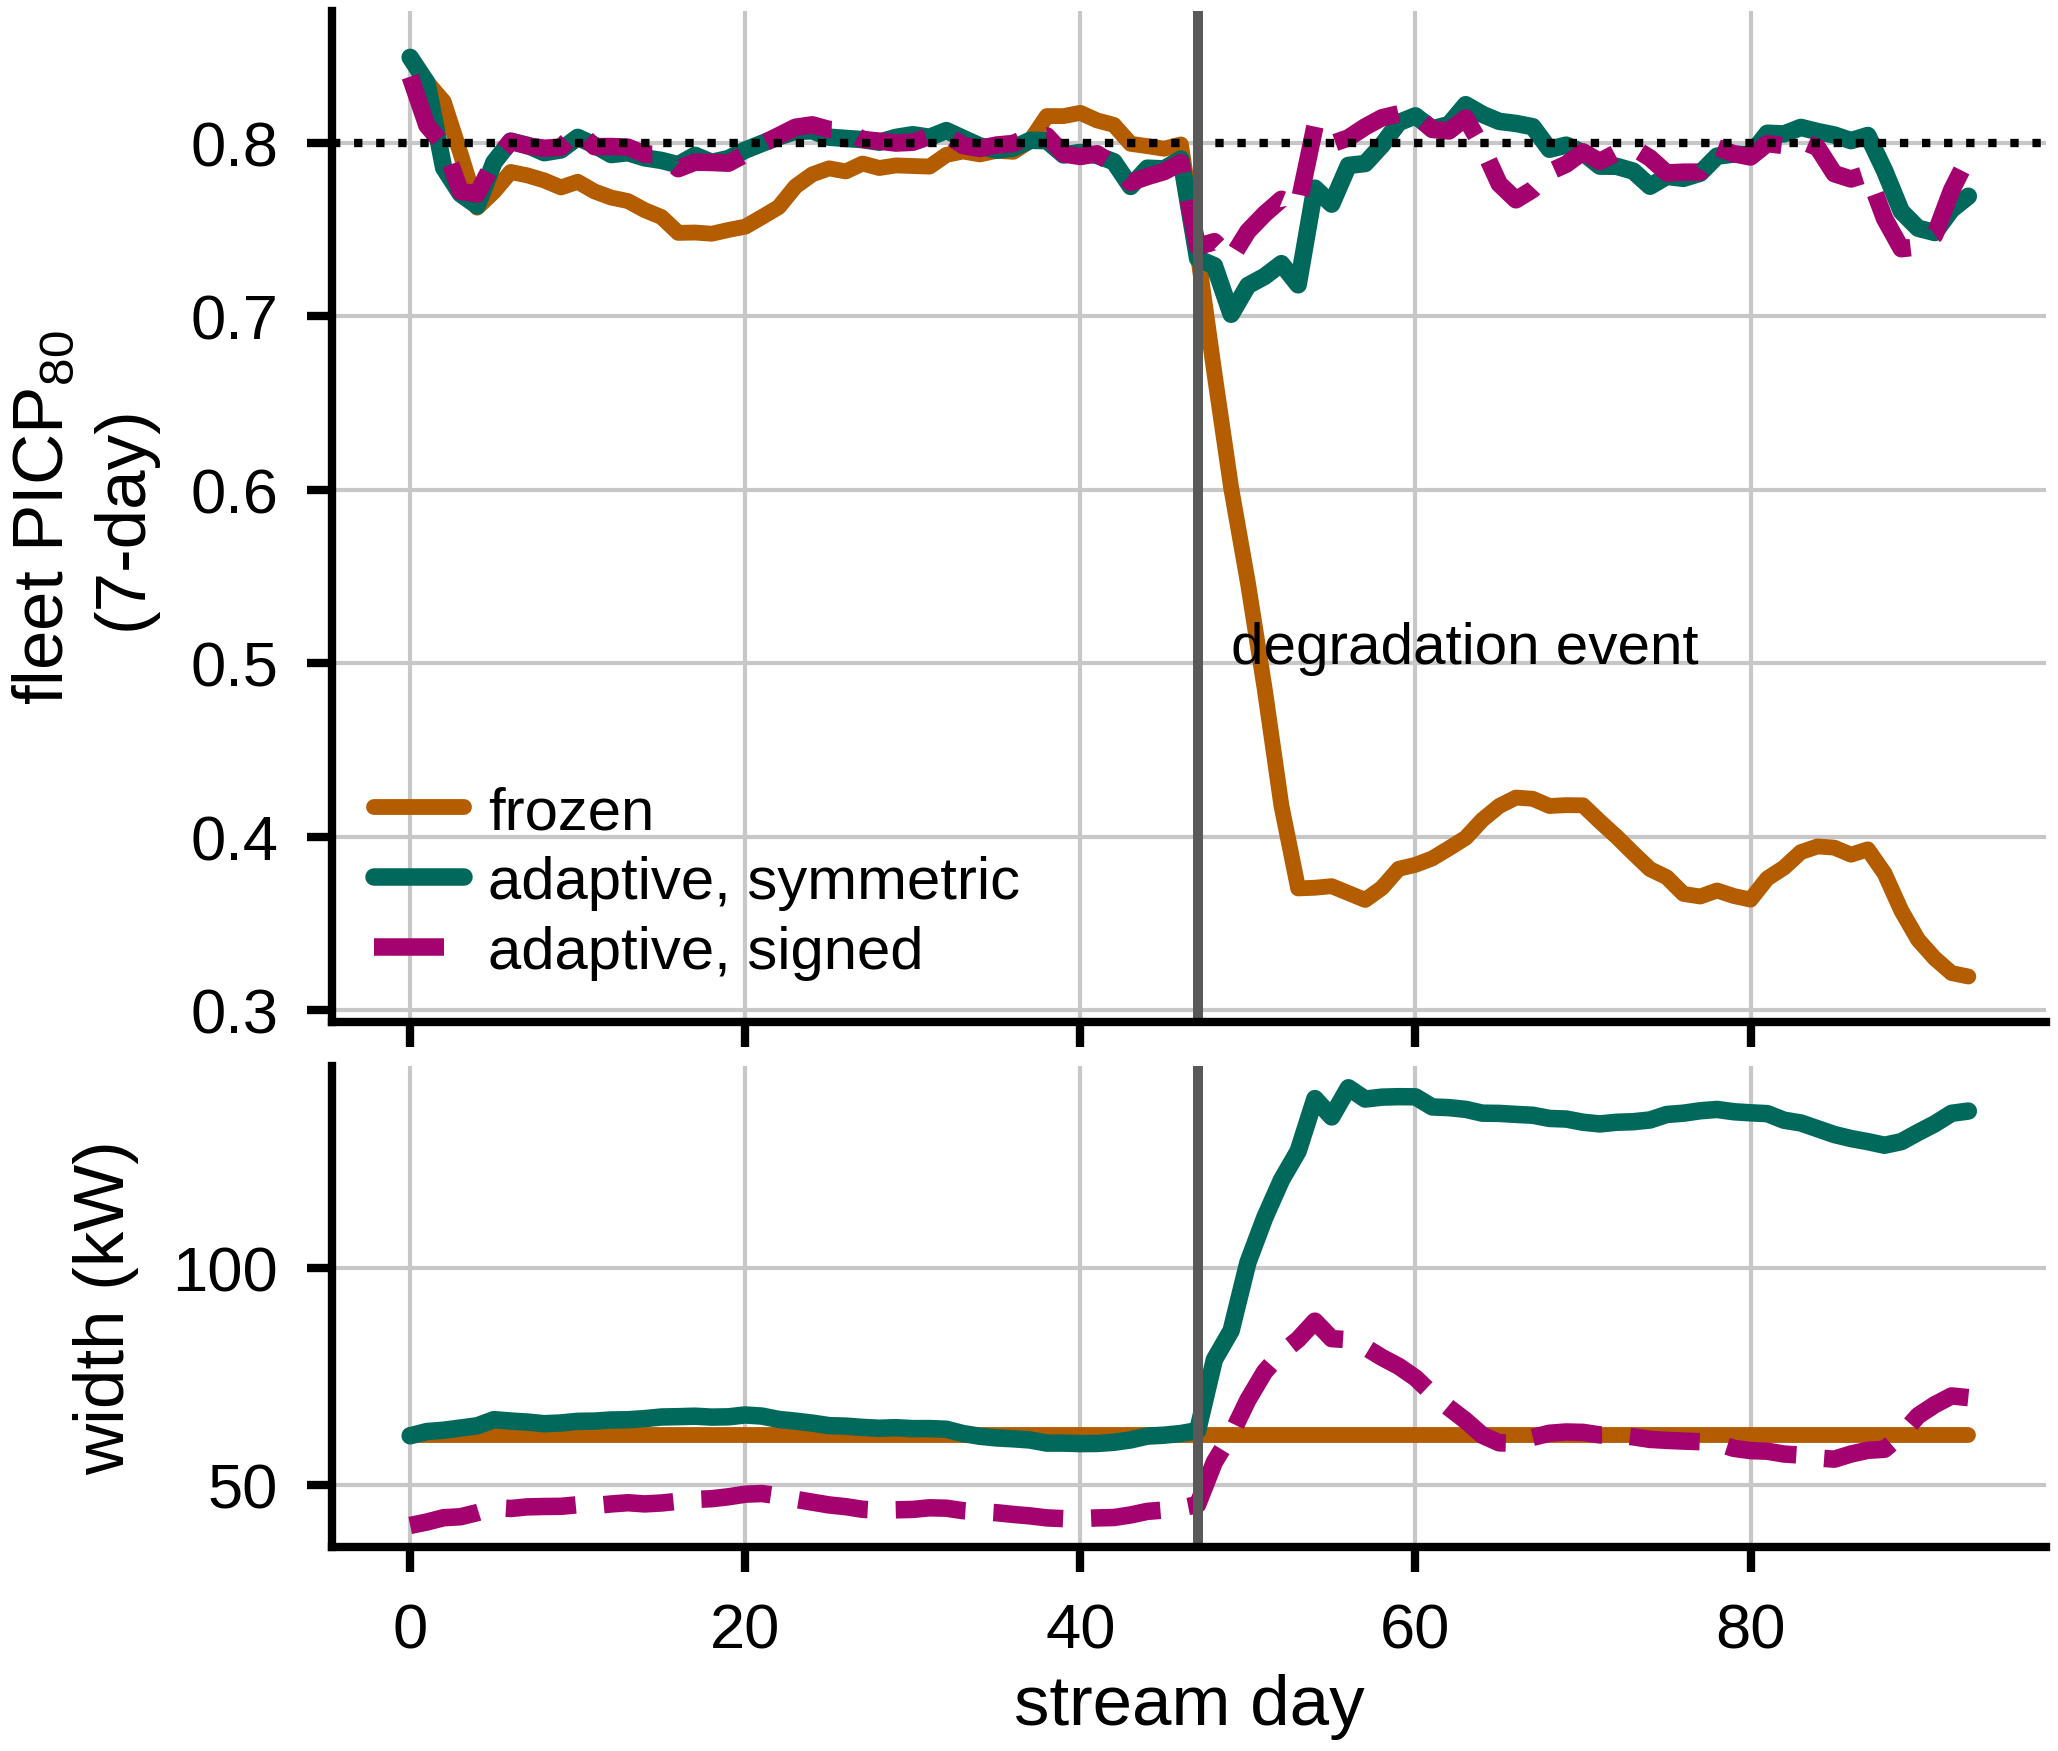

In [9]:
import os, time
from IPython.display import Image, display
p = os.path.join(OUT_DIR, "dt_live.png")
print(time.strftime("%H:%M:%S", time.localtime(os.path.getmtime(p))))
display(Image(filename=p))

In [ ]:
exec(open(f"{PROJECT_DIR}/twin_live_signed_v2.py").read())

60 buildings, 94 stream days, event at day 47
saved twin_running.gif (signed score)

final fleet PICP (last 7 days): 0.792
steady-state width (last 30 days): 61.8 kW


In [ ]:
from IPython.display import Image as IPImage, display
display(IPImage(filename=os.path.join(OUT_DIR, "twin_running.gif")))

<IPython.core.display.Image object>